In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os


SAVE_DIR = "../evaluation/plots/diabetes"
os.makedirs(SAVE_DIR, exist_ok=True)

df=pd.read_csv('../data/processed/diabetes/diabetes_processed.csv')
df.head()

,Glucose,BMI,Insulin,Age,prognosis
0,148,33.6,37,50,1
1,85,26.6,37,31,0
2,183,23.3,37,32,1
3,89,28.1,94,21,0
4,137,43.1,168,33,1


In [2]:
#dataset inf
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2768 entries, 0 to 2767
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Glucose    2768 non-null   int64  
 1   BMI        2768 non-null   float64
 2   Insulin    2768 non-null   int64  
 3   Age        2768 non-null   int64  
 4   prognosis  2768 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 108.2 KB


,Glucose,BMI,Insulin,Age,prognosis
count,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000
mean,121.863439,32.591077,97.906069,33.132225,0.343931
std,30.503499,7.103578,100.516123,11.777230,0.475104
min,44.000000,18.200000,14.000000,21.000000,0.000000
25%,99.000000,27.575000,37.000000,24.000000,0.000000
50%,117.000000,32.200000,37.000000,29.000000,0.000000
75%,141.000000,36.625000,130.000000,40.000000,1.000000
max,199.000000,80.600000,846.000000,81.000000,1.000000


In [3]:
df.isnull().sum()

Glucose      0
BMI          0
Insulin      0
Age          0
prognosis    0
dtype: int64

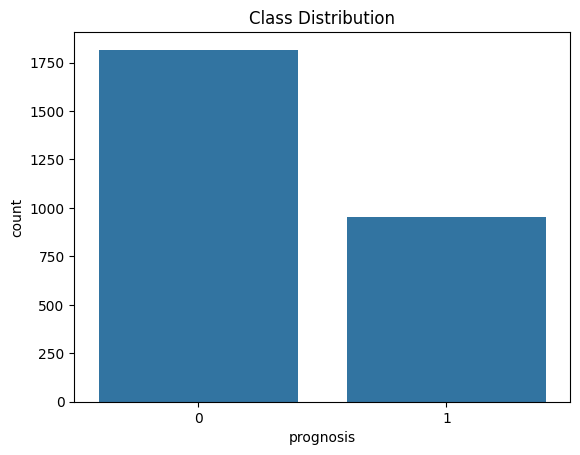

In [4]:
#class distribution
sns.countplot(x='prognosis',data=df)
plt.title('Class Distribution')
plt.savefig(f'{SAVE_DIR}/class_distribution_diabetes.png',dpi=300,bbox_inches='tight')
plt.show()

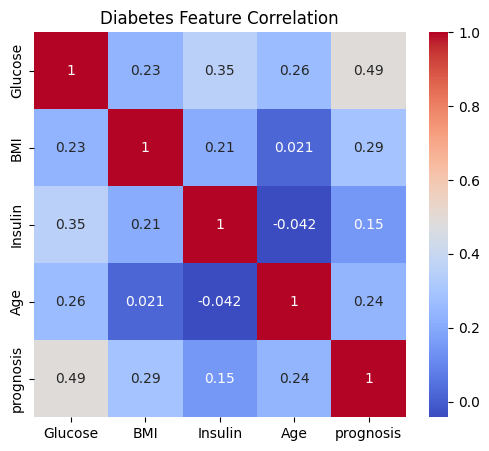

In [5]:
#correlation
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title("Diabetes Feature Correlation")

plt.savefig(f'{SAVE_DIR}/correlation_heatmap.png',dpi=300,bbox_inches='tight')
plt.show()

### Correlation Analysis – Diabetes Dataset

- Glucose exhibits the strongest positive correlation with diabetes status, confirming its role as the primary diagnostic biomarker.
- BMI and age show moderate correlations, indicating their contribution as metabolic and lifestyle risk factors.
- Insulin displays weaker correlation, reflecting variability and measurement noise.
- These findings support a multivariate approach rather than reliance on glucose alone.


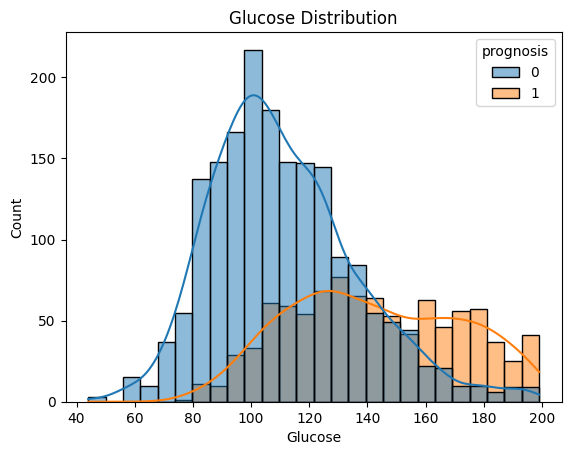

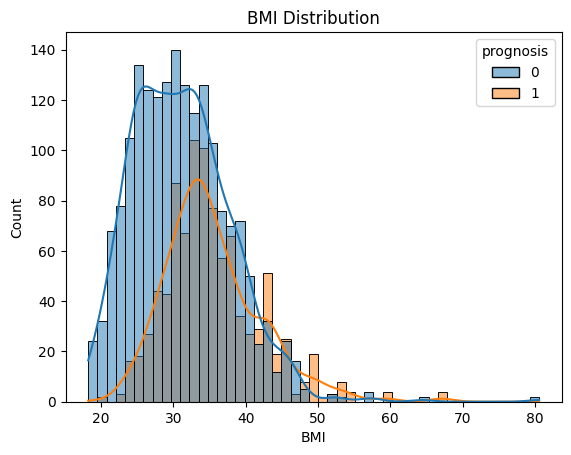

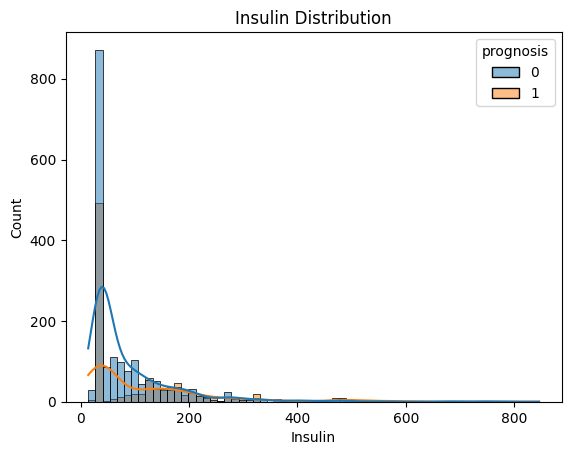

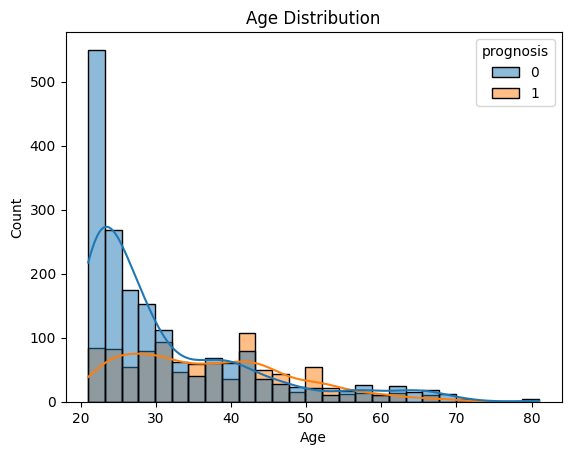

In [6]:
for col in df.columns:
    if col !="prognosis":
        plt.figure()
        sns.histplot(data=df,x=col,hue='prognosis',kde=True)
        plt.title(f'{col} Distribution')

        plt.savefig(f'{SAVE_DIR}/{col}_distribution.png',dpi=300,bbox_inches='tight')
        plt.show()

### Feature Distribution – Glucose

- Glucose levels show clear separation between diabetic and non-diabetic individuals.
- Diabetic patients exhibit higher glucose values, with the distribution shifted toward elevated ranges.
- Limited overlap occurs in intermediate glucose levels, corresponding to borderline or pre-diabetic cases.
- Overall, glucose demonstrates strong discriminative ability.


### Feature Distribution – BMI

- Diabetic individuals tend to have higher BMI values compared to non-diabetic individuals.
- Substantial overlap exists between the two groups, indicating that BMI alone cannot diagnose diabetes.
- BMI serves as an important metabolic risk factor contributing to diabetes susceptibility.


### Feature Distribution – Insulin

- Insulin values exhibit a highly skewed distribution with substantial variability.
- Considerable overlap exists between diabetic and non-diabetic groups.
- These patterns reflect measurement variability and treatment effects, indicating that insulin is a supporting rather than primary diagnostic feature.


### Feature Distribution – Age (Diabetes)

- Diabetic individuals tend to be older on average compared to non-diabetic individuals.
- Significant overlap exists across age groups, indicating that age alone is insufficient for diabetes diagnosis.
- Age functions as a supporting demographic risk factor.


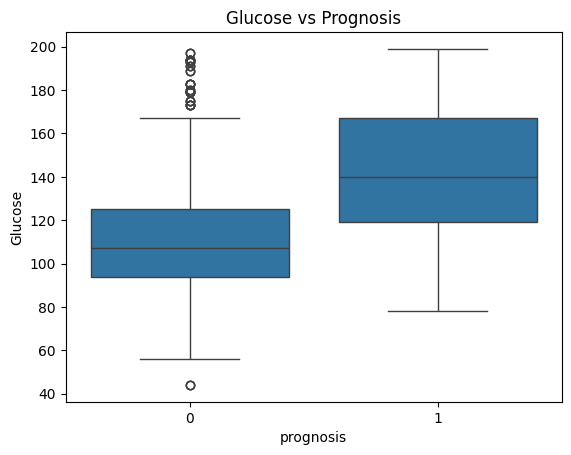

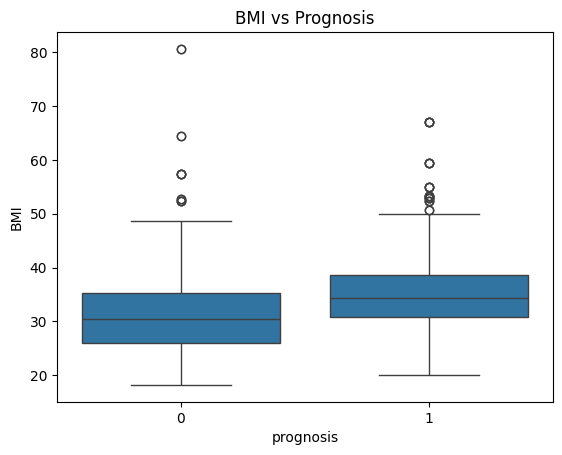

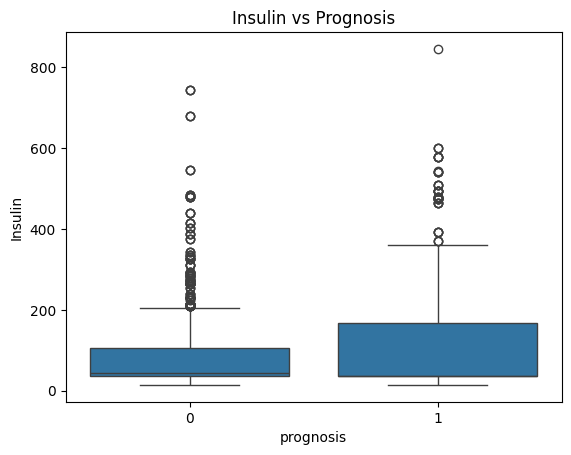

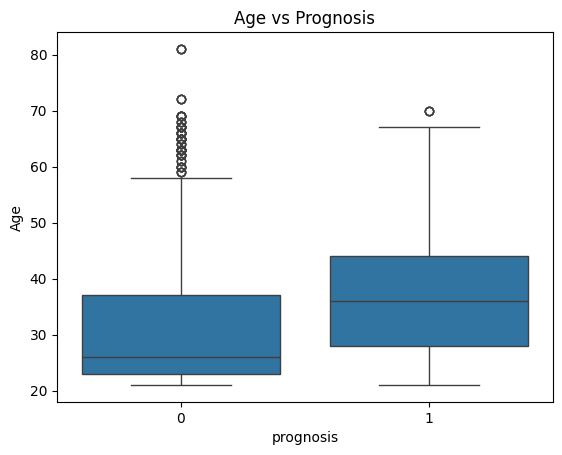

In [7]:
for col in df.columns:
    if col != "prognosis":
        plt.figure()
        sns.boxplot(x="prognosis", y=col, data=df)
        plt.title(f"{col} vs Prognosis")

        plt.savefig(f"{SAVE_DIR}/{col}_boxplot.png",
                    dpi=300,
                    bbox_inches="tight")
        plt.show()


### Boxplot Analysis – Glucose vs Prognosis

- Diabetic individuals exhibit substantially higher median glucose levels compared to non-diabetic individuals.
- The interquartile range for diabetics is shifted toward higher glucose values, indicating strong discriminative power.
- Limited overlap occurs in intermediate ranges, corresponding to borderline or pre-diabetic cases.
- Glucose emerges as the primary diagnostic biomarker for diabetes.


### Boxplot Analysis – BMI vs Prognosis

- Diabetic individuals tend to have higher median BMI values compared to non-diabetic individuals.
- Significant overlap between groups indicates that BMI alone is insufficient for diabetes diagnosis.
- BMI functions as a contributing metabolic risk factor rather than a primary indicator.


### Boxplot Analysis – Insulin vs Prognosis

- Insulin values exhibit high variability and extreme outliers in both diabetic and non-diabetic groups.
- Considerable overlap between the two classes suggests limited discriminative ability.
- These patterns reflect measurement noise and treatment effects, indicating that insulin serves as a supporting feature.


### Boxplot Analysis – Age vs Prognosis (Diabetes)

- Diabetic individuals exhibit a higher median age compared to non-diabetic individuals.
- Substantial overlap between groups indicates that age alone is insufficient for diabetes classification.
- Age acts as a supporting demographic risk factor.



- Among the analyzed features, glucose demonstrates the strongest separation between diabetic and non-diabetic individuals.
- BMI and age contribute as metabolic and demographic risk factors, while insulin shows high variability and limited standalone discriminative power.
- These observations support a multivariate diabetes prediction approach rather than reliance on a single biomarker.

